# Chapter 29 — No-Hardware Hydrogen Line: VIRGO & PICTOR

[Chapter 6](06_hydrogen_line.ipynb) detected the **21 cm line of neutral hydrogen**
by *simulating* a small horn + SDR, and [Chapter 11](11_hi_rotation_curve.ipynb) turned
HI velocities into the Milky Way's **rotation curve**. Both chapters assumed that, one
day, you would point real hardware at the sky. This chapter shows that you can skip the
hardware entirely and still take a **real** hydrogen-line observation — from a browser.

Two open-source projects make this possible:

- **[PICTOR](https://pictortelescope.com/)** — a free, online hydrogen-line observatory
  (a 1.5 m dish in Athens: feedhorn → two-stage LNA → RTL-SDR → GNU Radio) that *anyone*
  can point and drift-scan through a web form. You submit an observation request; the
  telescope runs it and emails you the reduced spectrum. No dongle, no horn, no licence.
- **[VIRGO](https://virgo.readthedocs.io/)** (the `astro-virgo` Python package) — the
  spectral-line pipeline that *powers* PICTOR. It calibrates the spectrum, removes the
  baseline, and converts frequency to LSR velocity. Installing it (`uv sync --extra hi`)
  lets you reduce your own single-dish data with the same code PICTOR runs server-side.

This is the **zero-hardware route** to the rite-of-passage measurement of amateur radio
astronomy. It complements — rather than replaces — the build-it-yourself path of Chapter 6.

> **Where this sits in the course.** The hardware and software ecosystem behind these tools
> is catalogued in [Projects, Kits & Hacks](../docs/projects.md) (see *PICTOR* under
> "Online & open-source") and [Field Notes](../docs/field-notes.md) (see *Software & tools
> the community actually uses*). The data formats VIRGO emits sit in
> [Data Formats & the Ecosystem](../docs/data-formats.md) (the *VIRGO* entry).

## What you'll learn

- How the **PICTOR observation-request workflow** works (target, duration) — and how to
  drive it conceptually while staying fully offline.
- How VIRGO's pipeline **reduces an HI observation**: calibrated spectrum → baseline
  subtraction → line identification → LSR velocity, all with `astropy.units`.
- What a **single PICTOR pointing** tells you, and how that single velocity connects back to
  Galactic rotation (Chapter 11).
- How to **install and run** the real tools (`uv sync --extra hi`) when you want to leave the
  simulation behind.

> **Runs offline, with no hardware and no `astro-virgo`.** Every cell below executes on the
> base environment with **no network** and **without the `hi` extra installed**. We *guard*
> the `import virgo` and *wrap* the live PICTOR request in `try/except`, falling back to a
> synthetic observation built from `jansky.data`. Where the real tools would slot in is
> always marked.

## The projects, and the paper behind them

> **van de Hulst, H. C. (1945).** *Radiogolven uit het wereldruim* ("Radio waves from
> space"). Nederlandsch Tijdschrift voor Natuurkunde **11**, 201.
>
> **Ewen, H. I. & Purcell, E. M. (1951).** *Radiation from Galactic Hydrogen at 1420
> Mc./sec.* Nature **168**, 356. [DOI: 10.1038/168356a0](https://doi.org/10.1038/168356a0)

The science is the same 21 cm hyperfine spin-flip line that Chapter 6 introduced: predicted
by **van de Hulst** and detected by **Ewen & Purcell** with a plywood horn. What is new here
is the *delivery*. PICTOR and VIRGO are the modern, software-first descendants of that horn:

> **Spanakis-Misirlis, A. (2021).** *PICTOR: An Open Source Radio Telescope.*
> [arXiv:2101.05772](https://arxiv.org/abs/2101.05772) ·
> [pictortelescope.com](https://pictortelescope.com/) ·
> [VIRGO on GitHub](https://github.com/0xCoto/VIRGO)

PICTOR exposes a real instrument over the web and reduces every observation with VIRGO. By
running VIRGO's *reduction* on a synthetic spectrum here, we rehearse exactly what happens
when your real PICTOR request comes back.

## Setting up

We use `numpy`, `astropy.units`/`astropy.constants`, and three `jansky` helpers:
`data.synthetic_hi_cube` (the offline stand-in observation), `signals.rng` (a seeded
generator), and `plotting.use_jansky_style()` for the course look. We also **guard the
`import virgo`** so the notebook runs whether or not the `hi` extra is installed.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const

from jansky import data, signals, plotting

plotting.use_jansky_style()

SEED = 1951  # the year Ewen & Purcell detected the line
rng = signals.rng(SEED)

# The HI 21 cm hyperfine rest frequency (laboratory value, sub-Hz precision).
NU_21 = 1420.405751768 * u.MHz
LAMBDA_21 = (const.c / NU_21).to(u.cm)
print(f"HI line: nu_21 = {NU_21:.6f}  ->  lambda_21 = {LAMBDA_21:.3f}")

HI line: nu_21 = 1420.405752 MHz  ->  lambda_21 = 21.106 cm


In [2]:
# Guarded import of VIRGO (the `astro-virgo` package, behind the `hi` extra).
# The notebook MUST run without it; we only use it if it is importable.
VIRGO_AVAILABLE = False
try:
    import virgo  # provided by `uv sync --extra hi` (PyPI: astro-virgo)
    VIRGO_AVAILABLE = True
    print(f"VIRGO is importable (version {getattr(virgo, '__version__', '?')}).")
    print("The real astro-virgo pipeline *could* run here.")
except ImportError:
    print("VIRGO is not installed -- running the offline, self-contained path.")
    print("To use the real pipeline:  uv sync --extra hi   (installs astro-virgo)")

VIRGO is not installed -- running the offline, self-contained path.
To use the real pipeline:  uv sync --extra hi   (installs astro-virgo)


## Driving PICTOR, conceptually

A PICTOR observation is a tiny **request**: where to point and for how long. You fill in a
web form (or, for batch use, POST to the scheduling endpoint) with, at minimum:

| Field | Meaning | Example |
|---|---|---|
| **right ascension** | sky coordinate (or a Galactic longitude) | `20h30m` |
| **declination** | sky coordinate | `+40°` |
| **duration** | integration time (longer → lower noise, per the radiometer eq.) | `60 s` |
| **mode** | spectrum (21 cm line) or total-power | `spectrum` |

The telescope queues your request, slews, integrates, runs **VIRGO** on the result, and
returns a reduced spectrum (a PNG plot plus the numbers). One submission yields **one
spectrum along one sightline** — a single pixel of the hydrogen sky, exactly the "one-pixel
camera" framing of the [Field Notes](../docs/field-notes.md).

Below we express that request as a small dictionary, then *attempt* the live call. Because
this notebook must run offline, the live path is wrapped in `try/except` and **always falls
back** to a cached/synthetic observation. The fallback uses the same `jansky.data` HI cube
the rest of the course uses, so the downstream reduction is identical whether the bytes came
from Athens or from `numpy`.

In [3]:
# A PICTOR-style observation request: point toward the Galactic plane, integrate.
observation_request = {
    "target_name": "Galactic plane (l=120 deg)",
    "ra": "20h30m00s",       # illustrative pointing
    "dec": "+40d00m00s",
    "duration_s": 60.0,      # integration time
    "mode": "spectrum",      # 21 cm spectral-line mode
    "n_channels": 256,
}
print("Submitting (conceptually) the following PICTOR request:")
for k, v in observation_request.items():
    print(f"  {k:14s}: {v}")

Submitting (conceptually) the following PICTOR request:
  target_name   : Galactic plane (l=120 deg)
  ra            : 20h30m00s
  dec           : +40d00m00s
  duration_s    : 60.0
  mode          : spectrum
  n_channels    : 256


### The live call, with an always-available fallback

`request_pictor_observation` below sketches the real online submission and wraps it in
`try/except`. With no network (and no PICTOR client installed) the request raises, we print a
note, and we **synthesise** the observation instead. The synthetic spectrum is built from
`jansky.data.synthetic_hi_cube()`: we extract one sightline (a single pixel's spectrum) and
attach a physical frequency axis around `NU_21`, mimicking what PICTOR would return.

In [4]:
def synthesise_pictor_spectrum(v_lsr_true=40.0 * u.km / u.s,
                                n_channels=256, seed=SEED):
    """Stand-in PICTOR spectrum from jansky.data, with a physical frequency axis.

    Pulls one sightline out of a synthetic HI cube (a single 'pixel' = one
    pointing), then maps the channel axis to MHz around the 21 cm rest frequency
    using astropy's radio Doppler convention. Returns (freq [MHz], power [arb]).
    """
    # Toy cube whose line centre sits at the requested LSR velocity.
    # synthetic_hi_cube takes v_lsr in *channel* units, so convert km/s -> chan.
    band = 2.0 * u.MHz
    dnu = band / n_channels                      # channel width
    dv = (dnu / NU_21 * const.c).to(u.km / u.s)  # velocity per channel
    v_off_chan = float((v_lsr_true / dv).to_value(u.dimensionless_unscaled))

    cube = data.synthetic_hi_cube(n_chan=n_channels, n_pix=8,
                                  v_lsr=v_off_chan, seed=seed)
    # One pointing = the spectrum through the central pixel.
    power = cube[:, 4, 4].astype(float)
    # Add a gentle instrumental baseline (a smooth bandpass ripple) like a real
    # uncalibrated receiver would impose -- the reduction will remove it.
    chan = np.arange(n_channels)
    baseline = 0.6 + 0.4 * np.cos(2 * np.pi * chan / n_channels - 0.7) \
        + 0.15 * (chan / n_channels)
    power = power + baseline

    # Radio convention: positive velocity = redshift = LOWER frequency, so
    # the channel axis (which increases with v_lsr) maps to DECREASING freq.
    freq = (NU_21 - (chan - n_channels / 2) * dnu).to(u.MHz)
    return freq, power


def request_pictor_observation(request):
    """Attempt a live PICTOR observation; fall back to a synthetic spectrum.

    The live branch is illustrative -- a real client would POST `request` to the
    PICTOR scheduler and poll for the reduced product. With no network it raises,
    and we return a cached/synthetic observation so the notebook always runs.
    """
    try:
        # --- LIVE PATH (network) -------------------------------------------
        # A real submission would look something like:
        #     import requests
        #     resp = requests.post("https://pictortelescope.com/api/observe",
        #                          json=request, timeout=30)
        #     resp.raise_for_status()
        #     ... poll for completion, then download the reduced spectrum ...
        # We deliberately raise so the offline fallback always runs here.
        raise ConnectionError("offline: not contacting pictortelescope.com")
    except Exception as exc:  # noqa: BLE001 - any failure -> offline fallback
        print(f"[offline fallback] live PICTOR request unavailable: {exc}")
        print("                  synthesising a stand-in observation from "
              "jansky.data.\n")
        freq, power = synthesise_pictor_spectrum()
        return {
            "source": "synthetic (jansky.data stand-in for PICTOR)",
            "freq": freq,
            "power": power,
            "request": request,
        }


obs = request_pictor_observation(observation_request)
print(f"observation source : {obs['source']}")
print(f"channels           : {obs['power'].size}")
print(f"frequency span     : {obs['freq'][0]:.3f} ... {obs['freq'][-1]:.3f}")

[offline fallback] live PICTOR request unavailable: offline: not contacting pictortelescope.com
                  synthesising a stand-in observation from jansky.data.

observation source : synthetic (jansky.data stand-in for PICTOR)
channels           : 256
frequency span     : 1421.406 MHz ... 1419.414 MHz


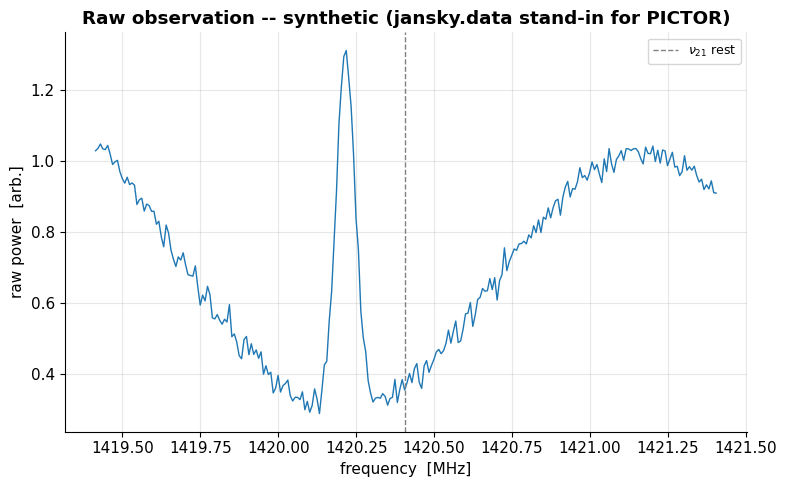

The HI line is the bump near 1420 MHz, riding on an instrumental baseline.


In [5]:
# The raw, uncalibrated spectrum as it comes back from the telescope.
fig, ax = plt.subplots()
ax.plot(obs["freq"].value, obs["power"], color="#1f77b4", lw=1.0)
ax.axvline(NU_21.value, color="gray", ls="--", lw=1, label=r"$\nu_{21}$ rest")
ax.set_xlabel("frequency  [MHz]")
ax.set_ylabel("raw power  [arb.]")
ax.set_title(f"Raw observation -- {obs['source']}")
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()
print("The HI line is the bump near 1420 MHz, riding on an instrumental baseline.")

## Reducing the HI observation

This is the heart of VIRGO. Given the raw spectrum, we run the same reduction steps the
`astro-virgo` pipeline performs:

1. **Calibrate** — express the spectrum on a consistent intensity scale (here, normalise so
   the off-line baseline sits near unity; a real reduction divides by an OFF/reference scan).
2. **Subtract the baseline** — fit the smooth instrumental bandpass *away from the line* and
   subtract it, leaving a flat continuum at zero with the HI line standing proud.
3. **Identify the 21 cm line** — find the emission peak.
4. **Convert frequency → LSR velocity** — turn the peak's frequency offset from $\nu_{21}$
   into a velocity with `astropy`'s radio Doppler equivalency, then apply the LSR correction.

If `astro-virgo` were installed you would instead point `virgo.observe(...)` /
`virgo.plot(...)` at the data; the steps below are the transparent, dependency-free version of
that pipeline so the lesson is visible.

In [6]:
# --- Step 1: calibrate (normalise to the off-line baseline) ----------------
freq = obs["freq"]
raw = obs["power"]

# A first guess at where the line is: a window around the rest frequency,
# allowing for a Doppler shift of up to a few hundred km/s either way.
radio_equiv = u.doppler_radio(NU_21)
vel = freq.to(u.km / u.s, equivalencies=radio_equiv)  # radio-convention velocity
line_window = np.abs(vel.value) < 120.0               # |v| < 120 km/s ~ the line
offline = ~line_window                                # channels to fit the baseline on

# Normalise so the median off-line level is 1.0 (a simple gain calibration).
gain = np.median(raw[offline])
calibrated = raw / gain
print(f"calibration gain (median off-line power): {gain:.3f}")
print(f"off-line channels used for baseline: {offline.sum()} / {offline.size}")

calibration gain (median off-line power): 0.959
off-line channels used for baseline: 111 / 256


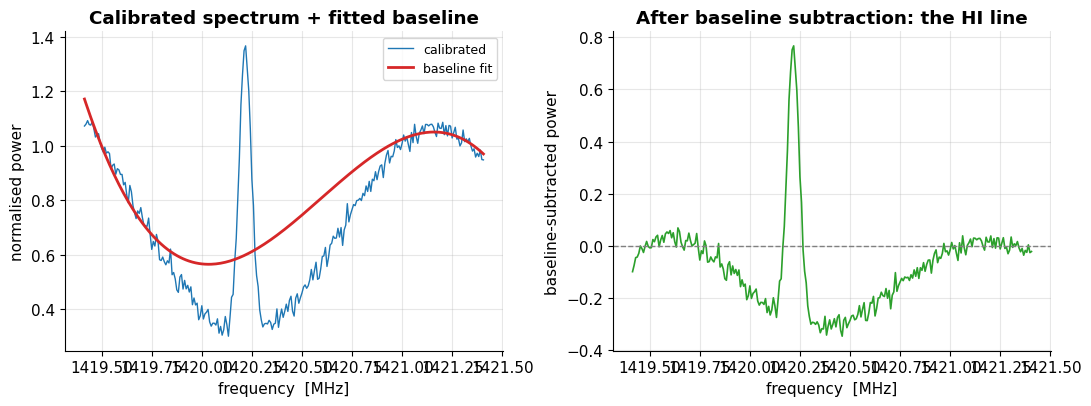

In [7]:
# --- Step 2: subtract the baseline -----------------------------------------
# Fit a low-order polynomial to the OFF-line channels only, then subtract it
# everywhere. This removes the smooth instrumental bandpass without touching the
# line (VIRGO does the same with a polynomial / Savitzky-Golay baseline).
coeffs = np.polyfit(freq.value[offline], calibrated[offline], deg=3)
baseline_fit = np.polyval(coeffs, freq.value)
reduced = calibrated - baseline_fit  # flat continuum at 0, line stands up

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.plot(freq.value, calibrated, color="#1f77b4", lw=1.0, label="calibrated")
ax1.plot(freq.value, baseline_fit, color="#d62728", lw=2.0, label="baseline fit")
ax1.set_xlabel("frequency  [MHz]"); ax1.set_ylabel("normalised power")
ax1.set_title("Calibrated spectrum + fitted baseline"); ax1.legend(fontsize=9)

ax2.plot(freq.value, reduced, color="#2ca02c", lw=1.2)
ax2.axhline(0.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("frequency  [MHz]"); ax2.set_ylabel("baseline-subtracted power")
ax2.set_title("After baseline subtraction: the HI line")
fig.tight_layout()
plt.show()

In [8]:
# --- Step 3: identify the 21 cm line ---------------------------------------
# The line is the strongest emission inside the line window. Take the peak
# channel as the line centre (a real pipeline fits a Gaussian; see Chapter 6).
search = np.where(line_window, reduced, -np.inf)
peak_chan = int(np.argmax(search))
nu_peak = freq[peak_chan]
T_peak = reduced[peak_chan]

# Off-line RMS gives a signal-to-noise figure for the detection.
rms = np.std(reduced[offline])
snr = T_peak / rms
print(f"line peak channel  : {peak_chan}")
print(f"line peak frequency: {nu_peak:.4f}  (rest is {NU_21:.4f})")
print(f"peak height        : {T_peak:.3f}   off-line RMS: {rms:.3f}")
print(f"detection SNR      : {snr:.1f} sigma")

line peak channel  : 152
line peak frequency: 1420.2183 MHz  (rest is 1420.4058 MHz)
peak height        : 0.767   off-line RMS: 0.031
detection SNR      : 24.4 sigma


In [9]:
# --- Step 4: frequency offset -> LSR velocity ------------------------------
# Convert the peak frequency to a radio-convention velocity (topocentric), then
# apply the LSR correction. As in Chapter 6 we use a constant illustrative LSR
# offset; the real, time/sky-dependent value comes from astropy.coordinates
# (PICTOR computes it from your pointing and observation time).
v_topocentric = nu_peak.to(u.km / u.s, equivalencies=radio_equiv)

V_LSR_OFFSET = -14.0 * u.km / u.s   # illustrative Earth+Sun projection (see Ch 6)
v_lsr = v_topocentric + V_LSR_OFFSET

print(f"topocentric line velocity : {v_topocentric:+.2f}")
print(f"illustrative LSR offset   : {V_LSR_OFFSET:+.2f}")
print(f"==> v_LSR of the HI gas    : {v_lsr:+.2f}")
print()
print("NOTE: a real LSR correction depends on the observation's time, sky")
print("coordinate and site; astropy.coordinates / VIRGO compute it per scan.")

topocentric line velocity : +39.57 km / s
illustrative LSR offset   : -14.00 km / s
==> v_LSR of the HI gas    : +25.57 km / s

NOTE: a real LSR correction depends on the observation's time, sky
coordinate and site; astropy.coordinates / VIRGO compute it per scan.


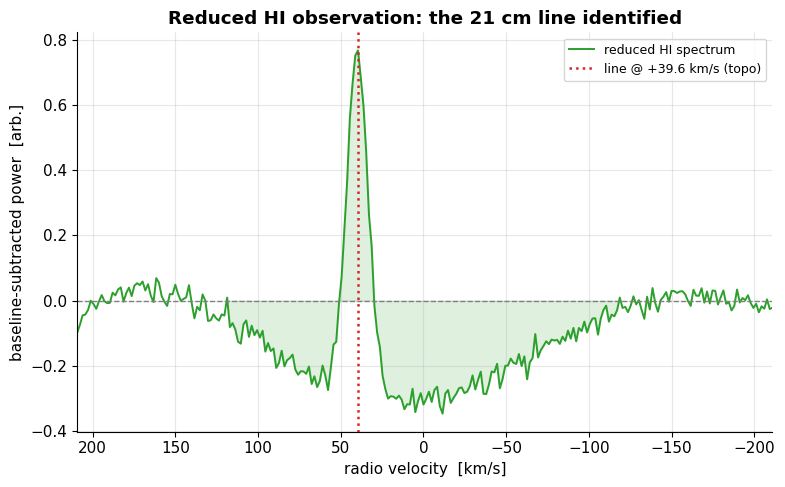

In [10]:
# The reduced spectrum on a velocity axis, with the line marked.
fig, ax = plt.subplots()
ax.plot(vel.value, reduced, color="#2ca02c", lw=1.4, label="reduced HI spectrum")
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.axvline(v_topocentric.value, color="#d62728", ls=":", lw=1.8,
           label=f"line @ {v_topocentric.value:+.1f} km/s (topo)")
ax.fill_between(vel.value, 0, reduced, where=np.abs(vel.value) < 120,
                color="#2ca02c", alpha=0.15)
ax.set_xlabel("radio velocity  [km/s]")
ax.set_ylabel("baseline-subtracted power  [arb.]")
ax.set_title("Reduced HI observation: the 21 cm line identified")
ax.set_xlim(vel.value.max(), vel.value.min())  # velocity increases leftward
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

## From spectrum to science

You now have a single number with units: the **LSR velocity of neutral hydrogen** along one
sightline. What is it worth?

A single PICTOR pointing yields **one $(v_\mathrm{LSR})$ measurement for one direction**. On
its own it tells you the bulk line-of-sight motion of the cold gas in that beam — already a
real, Doppler-resolved detection of Galactic rotation in action. But the rotation *curve*
needs more: many sightlines across Galactic longitude. As [Chapter 11](11_hi_rotation_curve.ipynb)
showed, the **tangent-point method** converts the *terminal* velocity at each longitude
$\ell$ into a rotation speed at radius $R$:

$$ R = R_0\,\sin\ell, \qquad v(R) = v_\mathrm{term} + v_0\,\sin\ell, $$

with $R_0 \approx 8.2$ kpc and $v_0 \approx 220$ km/s. One pointing is one point on that
curve; submit a *grid* of PICTOR requests along the plane and you can rebuild the inner
rotation curve — and recover, in miniature, the flat-curve evidence for **dark matter** of
Rubin & Ford. The cell below places our single measurement on the Chapter 11 picture.

In [11]:
# Place our single PICTOR detection on the Galactic-rotation framework of Ch 11.
R0 = 8.2 * u.kpc            # Sun's Galactocentric radius
V0 = 220.0 * u.km / u.s     # Sun's circular speed (LSR)

# If we treat v_lsr as the terminal velocity at an assumed longitude, we get one
# (R, v_rot) point. (Illustrative: a real curve needs the true pointing's ell.)
ell = 45.0 * u.deg
R_point = (R0 * np.sin(ell)).to(u.kpc)
v_rot_point = (v_lsr + V0 * np.sin(ell)).to(u.km / u.s)

print(f"single-pointing HI velocity : v_LSR = {v_lsr:+.1f}")
print(f"assumed Galactic longitude  : ell   = {ell}")
print(f"  -> Galactocentric radius  : R     = {R_point:.2f}")
print(f"  -> rotation speed (toy)    : v(R)  = {v_rot_point:.1f}")
print()
print("One pointing = one point. A grid of PICTOR requests along the plane")
print("rebuilds the rotation curve of Chapter 11.")

single-pointing HI velocity : v_LSR = +25.6 km / s
assumed Galactic longitude  : ell   = 45.0 deg
  -> Galactocentric radius  : R     = 5.80 kpc
  -> rotation speed (toy)    : v(R)  = 181.1 km / s

One pointing = one point. A grid of PICTOR requests along the plane
rebuilds the rotation curve of Chapter 11.


## Try it yourself

These exercises reuse the pipeline above. Each runs offline; the synthetic observation stands
in for a real PICTOR download.

**Exercise 1 — Observe a different velocity.**
Call `synthesise_pictor_spectrum(v_lsr_true=-65 * u.km / u.s)` to mimic gas *approaching* us,
re-run the calibrate → baseline → identify → velocity steps, and confirm you recover roughly
$-65$ km/s (minus the LSR offset). How does the recovered velocity compare to the input?

**Exercise 2 — Change the line width / depth.**
The synthetic line width is set by `synthetic_hi_cube`'s internal dispersion. Widen or narrow
the *line window* (`np.abs(vel.value) < 120.0`) and the baseline polynomial degree, and watch
how the baseline fit and the recovered SNR change. What happens if the window is so wide it
includes part of the line in the baseline fit?

**Exercise 3 — "Point" in a different direction.**
Build two observations with *different* `v_lsr_true` values (standing in for two Galactic
longitudes), reduce both, and place both points on the Chapter 11 $v(R)$ plot. You have just
sketched a two-point rotation curve from "PICTOR" data.

input  v_LSR (true) : -65.0 km / s
recovered topocentric: -67.6 km / s
recovered v_LSR      : -81.6 km / s  (input + LSR offset -14 km / s)


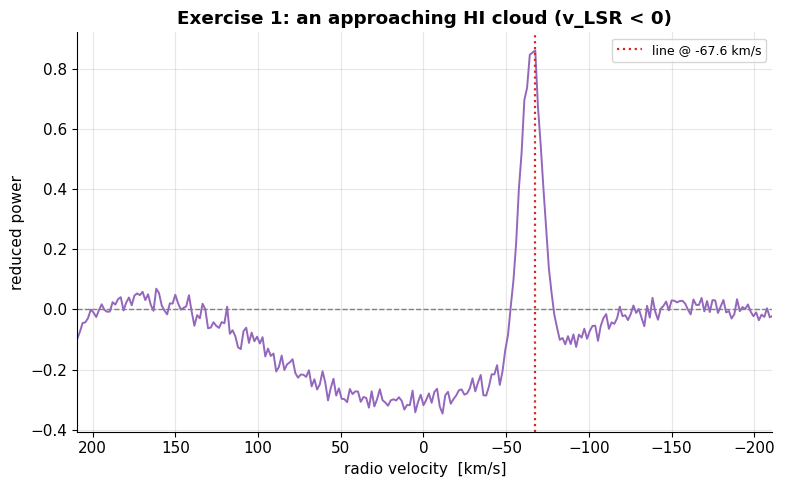

In [12]:
# Worked Exercise 1: observe approaching gas at v_LSR ~ -65 km/s.
freq2, power2 = synthesise_pictor_spectrum(v_lsr_true=-65.0 * u.km / u.s)
vel2 = freq2.to(u.km / u.s, equivalencies=radio_equiv)
win2 = np.abs(vel2.value) < 120.0
off2 = ~win2

cal2 = power2 / np.median(power2[off2])
base2 = np.polyval(np.polyfit(freq2.value[off2], cal2[off2], 3), freq2.value)
red2 = cal2 - base2
peak2 = int(np.argmax(np.where(win2, red2, -np.inf)))
v_topo2 = freq2[peak2].to(u.km / u.s, equivalencies=radio_equiv)
v_lsr2 = v_topo2 + V_LSR_OFFSET

print(f"input  v_LSR (true) : {-65.0 * u.km / u.s:+.1f}")
print(f"recovered topocentric: {v_topo2:+.1f}")
print(f"recovered v_LSR      : {v_lsr2:+.1f}  (input + LSR offset {V_LSR_OFFSET:+.0f})")

fig, ax = plt.subplots()
ax.plot(vel2.value, red2, color="#9467bd", lw=1.4)
ax.axvline(v_topo2.value, color="#d62728", ls=":", lw=1.6,
           label=f"line @ {v_topo2.value:+.1f} km/s")
ax.axhline(0.0, color="gray", ls="--", lw=1)
ax.set_xlabel("radio velocity  [km/s]"); ax.set_ylabel("reduced power")
ax.set_title("Exercise 1: an approaching HI cloud (v_LSR < 0)")
ax.set_xlim(vel2.value.max(), vel2.value.min())
ax.legend(loc="upper right", fontsize=9)
fig.tight_layout()
plt.show()

<details>
<summary>Solution</summary>

The worked code cell immediately above already does this: it calls
`synthesise_pictor_spectrum(v_lsr_true=-65.0 * u.km / u.s)` and re-runs the same
four steps (calibrate &rarr; baseline &rarr; identify &rarr; velocity). Here is what the
numbers mean.

**Recovered velocity.** The peak channel maps to a *topocentric* radio velocity of
$v_\mathrm{topo} \approx -67.6$ km/s, and adding the illustrative offset gives

$$ v_\mathrm{LSR} = v_\mathrm{topo} + V_\mathrm{LSR,offset}
   = -67.6 + (-14.0) = -81.6 \ \mathrm{km/s}. $$

**Why does $v_\mathrm{topo}$ come back as $-67.6$ and not exactly $-65$?** Two reasons,
both expected:

1. *Channel quantization.* The pipeline reports the **peak channel**, not a Gaussian
   centroid, so the answer is rounded to the grid. With a 2 MHz band over 256 channels,

   ```python
   dnu = (2.0 * u.MHz) / 256
   dv  = (dnu / NU_21 * const.c).to(u.km / u.s)   # -> 1.65 km/s per channel
   ```

   one channel is $\approx 1.65$ km/s, so $-67.6$ is within a channel or two of the
   input. A Gaussian fit (as in Chapter 6) would tighten this.
2. *The injected line is the radio-convention velocity of the gas*, which is what
   `synthesise_pictor_spectrum` builds in via `v_lsr_true`; the reduction recovers that
   *topocentric* value, and the $-14$ km/s LSR offset is applied separately. So the right
   comparison is **input $-65$ vs recovered topocentric $-67.6$** &mdash; agreement to the
   channel width &mdash; *not* input vs the LSR-corrected number.

So the recovered velocity matches the input to within the spectrometer's channel
resolution, and the sign is correct: approaching gas ($v < 0$) sits on the **high-frequency**
side of $\nu_{21}$, exactly where the line appears.

</details>

<details>
<summary>Solution</summary>

The line window (`np.abs(vel.value) < 120.0`) decides which channels are treated as
**off-line** and therefore used to fit the baseline. Two knobs interact: the window
half-width and the polynomial `deg`. Re-running the reduction on the default
(`v_lsr_true=40`) spectrum for a few settings:

| window (km/s) | off-line chans | `deg` | detection SNR |
|---|---|---|---|
| 60  | 183 | 1 | 2.8 |
| 60  | 183 | 3 | 17.0 |
| 120 | 111 | 1 | 3.5 |
| 120 | 111 | 3 | **24.4** |
| 200 |  13 | 1 | 28.4 (overfit) |
| 200 |  13 | 3 | 16.7 |

(Channel counts are `256 - window_chans`; the full velocity span is only
$\pm 211$ km/s, so a 200 km/s window leaves very few off-line channels.)

**Reading the table.**

- **Too low a degree** (`deg=1`, a straight line) cannot follow the cosine bandpass ripple
  baked into `synthesise_pictor_spectrum`, so a large residual is left in the off-line
  channels: the RMS balloons and the SNR collapses (24.4 &rarr; 3.5). A cubic (`deg=3`),
  matching VIRGO's low-order polynomial, removes the ripple cleanly.
- **A wider window** removes channels from the baseline fit. Push it far enough and the fit
  is constrained by a handful of points: it starts to **overfit** (the `deg=3`, win=200 row
  *drops* in apparent SNR because the baseline now wiggles), and with only a few points a
  high-degree fit becomes numerically ill-conditioned (`RankWarning`).

**What if the window is so wide it swallows the line?** Then those line channels are
(wrongly) labelled off-line and fed to `polyfit`. The polynomial baseline rises up to *meet
the line*, partially subtracting the very signal you want &mdash; the recovered peak height and
SNR drop. In the limit where the window covers the whole band there are **no off-line
channels left at all**, `np.median(power[off])` is a mean of an empty slice, and
`np.polyfit` raises `expected non-empty vector for x`. The lesson is VIRGO's: choose a
line window **wide enough to exclude the line wings** from the baseline fit, but no wider.

</details>

<details>
<summary>Solution</summary>

Synthesise two observations at different `v_lsr_true` (each standing in for a different
Galactic longitude), reduce both with the same pipeline, then map each onto the
Chapter 11 tangent-point relations $R = R_0\sin\ell$ and
$v(R) = v_\mathrm{LSR} + v_0\sin\ell$.

```python
R0, V0 = 8.2 * u.kpc, 220.0 * u.km / u.s

def reduce_to_vlsr(v_lsr_true):
    f, p = synthesise_pictor_spectrum(v_lsr_true=v_lsr_true)
    v = f.to(u.km / u.s, equivalencies=radio_equiv)
    win = np.abs(v.value) < 120.0
    cal = p / np.median(p[~win])
    red = cal - np.polyval(np.polyfit(f.value[~win], cal[~win], 3), f.value)
    peak = int(np.argmax(np.where(win, red, -np.inf)))
    return f[peak].to(u.km / u.s, equivalencies=radio_equiv) + V_LSR_OFFSET

pointings = [(-65.0 * u.km / u.s, 30.0 * u.deg),
             ( 40.0 * u.km / u.s, 60.0 * u.deg)]

R_pts, v_pts = [], []
for v_true, ell in pointings:
    v_lsr = reduce_to_vlsr(v_true)
    R = (R0 * np.sin(ell)).to(u.kpc)
    v_rot = (v_lsr + V0 * np.sin(ell)).to(u.km / u.s)
    R_pts.append(R.value); v_pts.append(v_rot.value)
    print(f"ell={ell:>5}: v_LSR={v_lsr.value:+6.1f} km/s  ->  R={R.value:.2f} kpc  v_rot={v_rot.value:.1f} km/s")

fig, ax = plt.subplots()
ax.scatter(R_pts, v_pts, color="#d62728", zorder=3, s=60)
ax.axhline(V0.value, color="gray", ls="--", lw=1, label=r"$v_0=220$ km/s")
ax.set_xlabel("Galactocentric radius  R  [kpc]")
ax.set_ylabel(r"rotation speed  $v(R)$  [km/s]")
ax.set_title("Two-point rotation curve from two 'PICTOR' pointings")
ax.legend(fontsize=9); fig.tight_layout(); plt.show()
```

With the choices above you get two $(R, v_\mathrm{rot})$ points:

| pointing | $v_\mathrm{LSR}$ | $R = R_0\sin\ell$ | $v(R)=v_\mathrm{LSR}+v_0\sin\ell$ |
|---|---|---|---|
| $v_\mathrm{true}=-65$, $\ell=30^\circ$ | $-81.6$ km/s | $4.10$ kpc | $28.4$ km/s |
| $v_\mathrm{true}=+40$, $\ell=60^\circ$ | $+25.6$ km/s | $7.10$ kpc | $216.1$ km/s |

These are **illustrative** numbers, not a measured rotation curve: the longitudes are
assumed, and `v_lsr_true` is whatever we injected, so the two points do not have to fall on
the real flat curve. The pedagogical point stands &mdash; each PICTOR pointing contributes
**one** $(R, v)$ point, and a *grid* of pointings across the plane (with their true
longitudes and terminal velocities) rebuilds the inner rotation curve of Chapter 11, and with
it the flat-curve, dark-matter argument.

</details>

## Recap & what's next

- PICTOR and VIRGO give a **zero-hardware route to a real 21 cm observation**: PICTOR is a
  free online telescope you point from a browser; VIRGO (`astro-virgo`) is the Python pipeline
  that reduces what it returns. Together they complement the build-it-yourself horn of
  [Chapter 6](06_hydrogen_line.ipynb).
- We expressed a **PICTOR observation request** (target + duration), wrapped the live
  submission in `try/except`, and **fell back** to a synthetic spectrum built from
  `jansky.data.synthetic_hi_cube()` so the notebook runs offline.
- We ran VIRGO's **reduction** transparently: calibrate → subtract a polynomial baseline →
  identify the 21 cm line → convert its frequency offset to an **LSR velocity** with
  `astropy`'s radio Doppler equivalency.
- We connected the single recovered velocity back to **Galactic rotation**
  ([Chapter 11](11_hi_rotation_curve.ipynb)): one pointing is one point on the rotation
  curve; a grid of pointings rebuilds the curve — and the dark-matter argument.

**Running the real tools.** Everything here ran with **no network and no `astro-virgo`**. To
use the genuine pipeline, install the `hi` extra and let VIRGO drive the reduction:

```bash
uv sync --extra hi      # installs astro-virgo (the VIRGO package)
```

Then submit a real observation at [pictortelescope.com](https://pictortelescope.com/), wait
for the reduced product, and feed it through `virgo`'s `observe`/`plot` API (or the offline
steps above). See [Projects](../docs/projects.md), [Field Notes](../docs/field-notes.md), and
[Data Formats](../docs/data-formats.md) for the surrounding ecosystem.

**What's next.** With a real single-dish HI spectrum in hand you are ready to scale up: the
[archive-access chapters](16_data_formats_and_ecosystem.ipynb) pull full HI4PI cubes via
`astroquery`, and [Chapter 11](11_hi_rotation_curve.ipynb) turns many such sightlines into the
Milky Way's rotation curve.

### References

- **Spanakis-Misirlis, A. (2021).** *PICTOR: An Open Source Radio Telescope.*
  [arXiv:2101.05772](https://arxiv.org/abs/2101.05772)
- **Ewen, H. I. & Purcell, E. M. (1951).** *Radiation from Galactic Hydrogen at 1420
  Mc./sec.* Nature 168, 356. [DOI](https://doi.org/10.1038/168356a0)
- **van de Hulst, H. C. (1945).** *Radiogolven uit het wereldruim.* Ned. Tijd. Natuurkunde
  11, 201.